1. Импорты

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import joblib
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')

print("Все библиотеки загружены")

Все библиотеки загружены


2. Загрузка данных

In [2]:
df = pd.read_csv('../data/sample_data.csv')
print(f"Данные загружены: {df.shape}")
df.head()

Данные загружены: (9000, 9)


,product_id,date,category,competitor_price,our_price,demand_index,stock_level,margin,optimal_price
0,0,2024-01-01,электроника,2244.85,2204.50,87,224,0.117,2182.68
1,0,2024-01-02,электроника,2464.89,2483.19,96,673,0.295,2241.22
2,0,2024-01-03,электроника,2283.04,2272.58,96,520,0.142,2207.69
3,0,2024-01-04,электроника,2267.14,2207.61,84,199,0.127,2178.26
4,0,2024-01-05,электроника,2186.52,2284.01,95,494,0.282,2236.19


3. Подготовка признаков

In [3]:
# Признаки и целевая переменная
features = ['competitor_price', 'our_price', 'demand_index', 'stock_level', 'margin', 'category']
target = 'optimal_price'

X = df[features]
y = df[target]

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Настройка MLflow для трекинга экспериментов.
# Так как ноутбук находится в project/notebooks, результаты будут сохраняться в project/mlruns.
mlflow.set_tracking_uri("file:../mlruns")
mlflow.set_experiment("price-monitoring-models")

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("MLflow experiment: price-monitoring-models")

2026/05/31 19:52:04 INFO mlflow.tracking.fluent: Experiment with name 'price-monitoring-models' does not exist. Creating a new experiment.


Train: (7200, 6), Test: (1800, 6)
MLflow experiment: price-monitoring-models


4. Пайплайн предобработки

In [4]:
# Разделяем признаки на числовые и категориальные
numeric_features = ['competitor_price', 'our_price', 'demand_index', 'stock_level', 'margin']
categorical_features = ['category']

# Препроцессор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

print("Препроцессор создан")

Препроцессор создан


4.1. Вспомогательная функция для MLflow

In [5]:
def evaluate_and_log_model(model_name, pipeline, params=None):
    """Обучает модель, считает метрики и сохраняет эксперимент в MLflow."""
    params = params or {}

    # Если случайно остался открытый run, закрываем его, чтобы не было конфликта.
    if mlflow.active_run() is not None:
        mlflow.end_run()

    with mlflow.start_run(run_name=model_name):
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        mlflow.log_param("model_name", model_name)
        mlflow.log_param("features", ", ".join(features))
        mlflow.log_param("target", target)
        mlflow.log_param("test_size", 0.2)
        mlflow.log_param("random_state", 42)

        for param_name, param_value in params.items():
            mlflow.log_param(param_name, param_value)

        mlflow.log_metric("mae", mae)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("r2", r2)

        # Сохраняем полный Pipeline: препроцессинг + модель.
        mlflow.sklearn.log_model(pipeline, artifact_path="model")

    return pipeline, y_pred, mae, rmse, r2

print("Функция evaluate_and_log_model готова")

Функция evaluate_and_log_model готова


5. Baseline: LinearRegression

In [6]:
# Модель 1: Linear Regression — baseline
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

pipeline_lr, y_pred_lr, mae_lr, rmse_lr, r2_lr = evaluate_and_log_model(
    model_name="Linear Regression",
    pipeline=pipeline_lr,
    params={"regressor": "LinearRegression"}
)

print("=== Linear Regression ===")
print(f"MAE:  {mae_lr:.2f} руб.")
print(f"RMSE: {rmse_lr:.2f} руб.")
print(f"R²:   {r2_lr:.4f}")

2026/05/31 19:52:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/31 19:52:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


=== Linear Regression ===
MAE:  173.27 руб.
RMSE: 223.81 руб.
R²:   0.9718


6. Ridge Regression

In [7]:
# Модель 2: Ridge Regression — линейная модель с регуляризацией
ridge_alpha = 1.0

pipeline_ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=ridge_alpha))
])

pipeline_ridge, y_pred_ridge, mae_ridge, rmse_ridge, r2_ridge = evaluate_and_log_model(
    model_name="Ridge Regression",
    pipeline=pipeline_ridge,
    params={"regressor": "Ridge", "alpha": ridge_alpha}
)

print("=== Ridge Regression ===")
print(f"MAE:  {mae_ridge:.2f} руб.")
print(f"RMSE: {rmse_ridge:.2f} руб.")
print(f"R²:   {r2_ridge:.4f}")

2026/05/31 19:52:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/31 19:52:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


=== Ridge Regression ===
MAE:  173.27 руб.
RMSE: 223.81 руб.
R²:   0.9718


7. Random Forest

In [8]:
# Модель 3: Random Forest — ансамблевая модель
rf_n_estimators = 100
rf_random_state = 42

pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=rf_n_estimators,
        random_state=rf_random_state
    ))
])

pipeline_rf, y_pred_rf, mae_rf, rmse_rf, r2_rf = evaluate_and_log_model(
    model_name="Random Forest",
    pipeline=pipeline_rf,
    params={
        "regressor": "RandomForestRegressor",
        "n_estimators": rf_n_estimators,
        "random_state": rf_random_state
    }
)

print("=== Random Forest ===")
print(f"MAE:  {mae_rf:.2f} руб.")
print(f"RMSE: {rmse_rf:.2f} руб.")
print(f"R²:   {r2_rf:.4f}")

2026/05/31 19:52:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/31 19:52:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


=== Random Forest ===
MAE:  131.01 руб.
RMSE: 190.15 руб.
R²:   0.9797


8. XGBoost

In [9]:
# Модель 4: XGBoost — градиентный бустинг
xgb_n_estimators = 100
xgb_learning_rate = 0.1
xgb_random_state = 42

pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(
        n_estimators=xgb_n_estimators,
        learning_rate=xgb_learning_rate,
        random_state=xgb_random_state
    ))
])

pipeline_xgb, y_pred_xgb, mae_xgb, rmse_xgb, r2_xgb = evaluate_and_log_model(
    model_name="XGBoost",
    pipeline=pipeline_xgb,
    params={
        "regressor": "XGBRegressor",
        "n_estimators": xgb_n_estimators,
        "learning_rate": xgb_learning_rate,
        "random_state": xgb_random_state
    }
)

print("=== XGBoost ===")
print(f"MAE:  {mae_xgb:.2f} руб.")
print(f"RMSE: {rmse_xgb:.2f} руб.")
print(f"R²:   {r2_xgb:.4f}")

2026/05/31 19:52:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/31 19:52:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


=== XGBoost ===
MAE:  136.28 руб.
RMSE: 191.12 руб.
R²:   0.9795


9. Сравнение моделей

In [10]:
# Сводная таблица
results = pd.DataFrame({
    'Модель': ['Linear Regression', 'Ridge', 'Random Forest', 'XGBoost'],
    'MAE (руб.)': [mae_lr, mae_ridge, mae_rf, mae_xgb],
    'RMSE (руб.)': [rmse_lr, rmse_ridge, rmse_rf, rmse_xgb],
    'R²': [r2_lr, r2_ridge, r2_rf, r2_xgb]
})

results = results.round(2)
results = results.sort_values('R²', ascending=False).reset_index(drop=True)

print("=" * 60)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("=" * 60)
print(results.to_string(index=False))

# Выделяем лучшую модель
best_model_name = results.iloc[0]['Модель']
print(f"\nЛучшая модель: {best_model_name}")

СРАВНЕНИЕ МОДЕЛЕЙ
           Модель  MAE (руб.)  RMSE (руб.)   R²
          XGBoost      136.28       191.12 0.98
    Random Forest      131.01       190.15 0.98
            Ridge      173.27       223.81 0.97
Linear Regression      173.27       223.81 0.97

Лучшая модель: XGBoost


9.1. Просмотр экспериментов MLflow

In [11]:
print("Эксперименты сохранены в MLflow.")
print("Чтобы открыть интерфейс MLflow, выполните в терминале из папки project:")
print("mlflow ui --backend-store-uri ./mlruns")
print("Затем откройте в браузере: http://127.0.0.1:5000")

Эксперименты сохранены в MLflow.
Чтобы открыть интерфейс MLflow, выполните в терминале из папки project:
mlflow ui --backend-store-uri ./mlruns
Затем откройте в браузере: http://127.0.0.1:5000


10. Визуализация сравнения

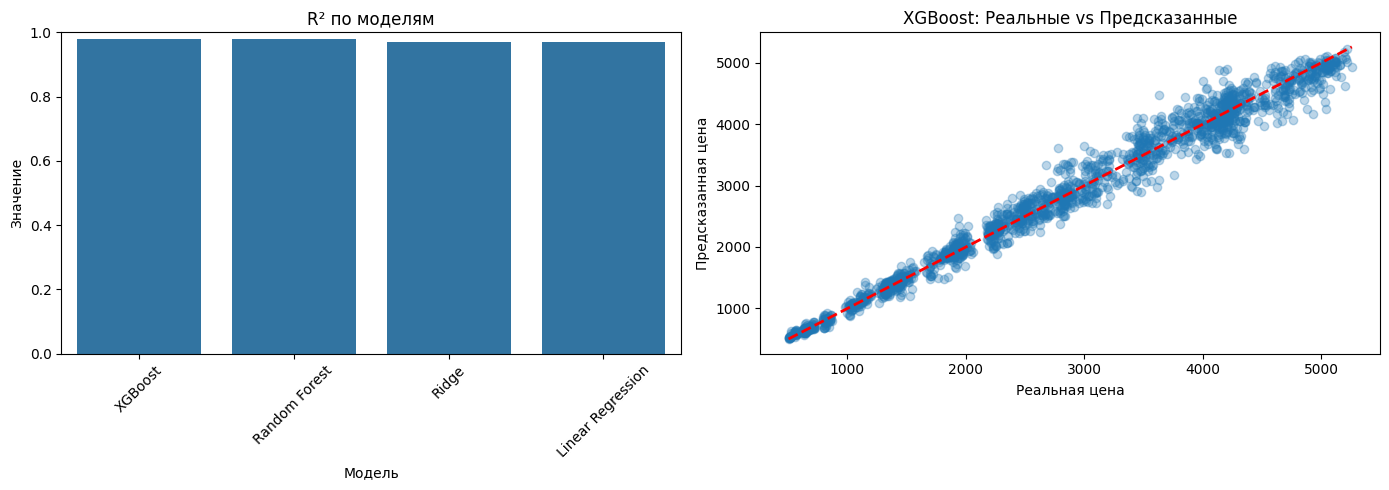

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График метрик
metrics_df = results.melt(id_vars='Модель', var_name='Метрика', value_name='Значение')
sns.barplot(data=metrics_df[metrics_df['Метрика'] == 'R²'], x='Модель', y='Значение', ax=axes[0])
axes[0].set_title('R² по моделям')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)

# Scatter: реальные vs предсказанные (лучшая модель)
pipeline_best = pipeline_xgb  # XGBoost как лучшая
y_pred_best = pipeline_best.predict(X_test)

axes[1].scatter(y_test, y_pred_best, alpha=0.3)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[1].set_xlabel('Реальная цена')
axes[1].set_ylabel('Предсказанная цена')
axes[1].set_title('XGBoost: Реальные vs Предсказанные')

plt.tight_layout()
plt.show()

11. Важность признаков

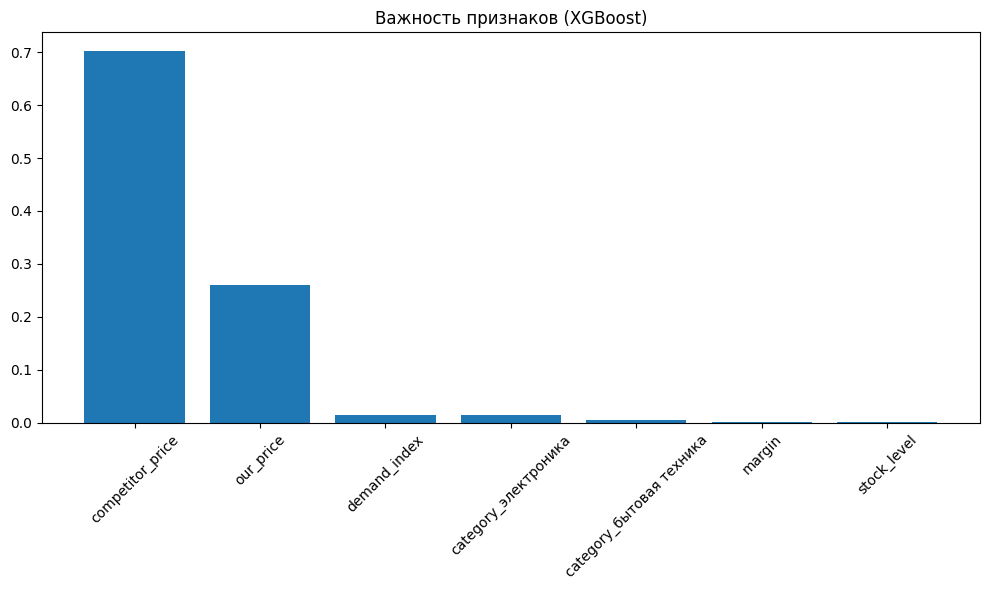

In [13]:
# Важность признаков для XGBoost
feature_names = numeric_features + list(
    pipeline_xgb.named_steps['preprocessor']
    .transformers_[1][1]
    .get_feature_names_out(categorical_features)
)

importances = pipeline_xgb.named_steps['regressor'].feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45)
plt.title('Важность признаков (XGBoost)')
plt.tight_layout()
plt.show()

12. Сохранение модели

In [14]:
# Сохраняем лучшую модель
model_path = '../artifacts/price_optimizer.pkl'
joblib.dump(pipeline_xgb, model_path)
print(f"Модель сохранена: {model_path}")
print(f"Итоговые метрики — MAE: {mae_xgb:.2f} руб., R²: {r2_xgb:.4f}")

Модель сохранена: ../artifacts/price_optimizer.pkl
Итоговые метрики — MAE: 136.28 руб., R²: 0.9795
